# t-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/t-test)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 21.01.2026

Der **t-Test** prüft, ob ein beobachteter Mittelwertsunterschied **echt** ist oder
nur durch Zufall bei der Stichprobenziehung entstanden ist.

**Kernidee: Signal / Rauschen**
$$t = \frac{\text{Signal (Mittelwertsunterschied)}}{\text{Rauschen (Standardfehler)}}$$

| Variante | Fragestellung | Beispiel |
|---|---|---|
| **Einstichproben-t-Test** | Stichproben-MW vs. bekannter Referenzwert | Schokoriegel: 48g vs. behauptete 50g |
| **Unabhängiger t-Test** | Zwei getrennte Gruppen | Medikament A vs. B (verschiedene Personen) |
| **Abhängiger t-Test** | Dieselben Personen zu 2 Zeitpunkten | Gewicht vor vs. nach der Diät |

**Voraussetzungen:**
- Metrisches Skalenniveau
- Annähernde Normalverteilung (ab n > 30 robust)
- Varianzhomogenität (nur beim unabhängigen t-Test – Levene-Test)
- Zufallsauswahl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import t as t_dist, norm as norm_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Warum brauchen wir den t-Test? (Signal vs. Rauschen)

**Beispiel (numiqo):** Studiendauer Männer vs. Frauen in Deutschland.

Selbst wenn Männer und Frauen in der **Grundgesamtheit** exakt gleich lange studieren,
wird deine Stichprobe fast nie einen Unterschied von genau 0 zeigen – das ist
**Rauschen** durch Zufall.

Der t-Test berechnet, wie wahrscheinlich dein beobachteter Unterschied durch
**reinen Zufall** entstanden ist, und trennt damit echtes Signal von Rauschen.

Zufälliger Unterschied durch Stichprobenziehung
MW Männer:  12.730 Semester  (wahrer MW: 13.2)
MW Frauen:   12.897 Semester  (wahrer MW: 13.2)
Differenz:   -0.167 Semester
t-Wert:      -0.2833
p-Wert:      0.7779  -> nicht signifikant (nur Zufall)

Obwohl kein echter Unterschied existiert, zeigt die Stichprobe
eine kleine Differenz – das ist das 'Rauschen'.


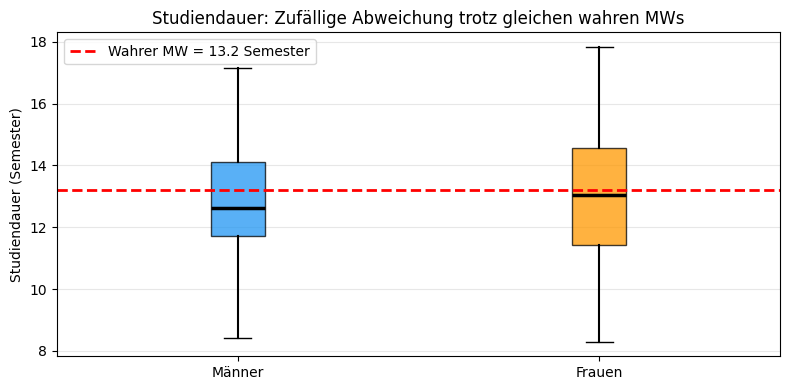

In [3]:
# Intuition: Signal vs. Rauschen
np.random.seed(42)
n = 30
studiendauer_m = pd.Series(np.random.normal(13.2, 2.5, n))
studiendauer_w = pd.Series(np.random.normal(13.2, 2.5, n))  # gleicher MW!

differenz_zufaellig = studiendauer_m.mean() - studiendauer_w.mean()
t_stat, p_wert = stats.ttest_ind(studiendauer_m, studiendauer_w)

print("Zufälliger Unterschied durch Stichprobenziehung")
print(f"MW Männer:  {studiendauer_m.mean():.3f} Semester  (wahrer MW: 13.2)")
print(f"MW Frauen:   {studiendauer_w.mean():.3f} Semester  (wahrer MW: 13.2)")
print(f"Differenz:   {differenz_zufaellig:.3f} Semester")
print(f"t-Wert:      {t_stat:.4f}")
print(f"p-Wert:      {p_wert:.4f}  -> {'signifikant' if p_wert < 0.05 else 'nicht signifikant (nur Zufall)'}")
print()
print("Obwohl kein echter Unterschied existiert, zeigt die Stichprobe")
print("eine kleine Differenz – das ist das 'Rauschen'.")

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([studiendauer_m, studiendauer_w], patch_artist=True,
                medianprops=dict(color="black", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], ["#2196F3", "#FF9800"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
ax.axhline(13.2, color="red", linestyle="--", linewidth=2,
           label="Wahrer MW = 13.2 Semester")
ax.set_title("Studiendauer: Zufällige Abweichung trotz gleichen wahren MWs")
ax.set_ylabel("Studiendauer (Semester)")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Männer", "Frauen"])
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Die drei t-Test-Varianten

### Formeln

**Einstichproben-t-Test:**
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n - 1$$

**Unabhängiger t-Test (gleiche Varianzen):**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \cdot \sqrt{1/n_1 + 1/n_2}}, \quad s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}, \quad df = n_1+n_2-2$$

**Abhängiger t-Test:**
$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \quad df = n - 1$$

wobei $\bar{d}$ der Mittelwert der Differenzen und $s_d$ deren Standardabweichung ist.

### Freiheitsgrade (df)

| Test | df |
|---|---|
| Einstichproben | $n - 1$ |
| Unabhängig | $n_1 + n_2 - 2$ |
| Abhängig | $n - 1$ (Anzahl Paare) |

## 3. Einstichproben-t-Test

**Wann:** Stichproben-Mittelwert vs. bekannten Referenzwert

**Beispiel (numiqo):** Schokoriegel-Hersteller behauptet 50 g – Stichprobe zeigt 48 g.
Ist die Abweichung signifikant?

- H₀: μ = 50 g
- H₁: μ ≠ 50 g

Einstichproben-t-Test: Schokoriegel
H0: mu = 50.0 g  |  H1: mu != 50.0 g

n:              30
Stichproben-MW: 47.341 g
Standardabw.:   3.150 g
Standardfehler: 0.5751 g
t-Wert:         (47.341 - 50.0) / 0.5751 = -4.6226
df:             29
p-Wert:         0.0001
95%-KI:         [46.165, 48.518] g

p=0.0001 < 0.05 -> H0 ablehnen
Die Riegel weichen signifikant vom Sollgewicht ab!
Kontrolle scipy: t=-4.6226, p=0.0001


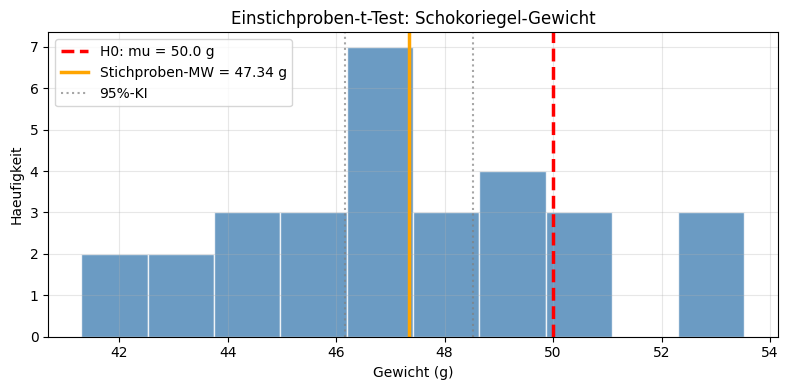

In [17]:
# Einstichproben-t-Test: Schokoriegel-Beispiel (numiqo)
np.random.seed(42)
n_s = 30
mu_null = 50.0   # behauptetes Sollgewicht
riegel   = pd.Series(np.random.normal(48.0, 3.5, n_s))

mw_s  = riegel.mean()
s_s   = riegel.std(ddof=1)
se_s  = s_s / np.sqrt(n_s)
t_s   = (mw_s - mu_null) / se_s
df_s  = n_s - 1
p_s   = 2 * t_dist.sf(abs(t_s), df=df_s)

ki_s  = t_dist.interval(0.95, df=df_s, loc=mw_s, scale=se_s)

print("Einstichproben-t-Test: Schokoriegel")
print(f"H0: mu = {mu_null} g  |  H1: mu != {mu_null} g")
print()
print(f"n:              {n_s}")
print(f"Stichproben-MW: {mw_s:.3f} g")
print(f"Standardabw.:   {s_s:.3f} g")
print(f"Standardfehler: {se_s:.4f} g")
print(f"t-Wert:         ({mw_s:.3f} - {mu_null}) / {se_s:.4f} = {t_s:.4f}")
print(f"df:             {df_s}")
print(f"p-Wert:         {p_s:.4f}")
print(f"95%-KI:         [{ki_s[0]:.3f}, {ki_s[1]:.3f}] g")
print()
alpha = 0.05
if p_s < alpha:
    print(f"p={p_s:.4f} < {alpha} -> H0 ablehnen")
    print("Die Riegel weichen signifikant vom Sollgewicht ab!")
else:
    print(f"p={p_s:.4f} >= {alpha} -> H0 nicht ablehnen")

# Verifikation
t_scipy, p_scipy = stats.ttest_1samp(riegel, popmean=mu_null)
print(f"Kontrolle scipy: t={t_scipy:.4f}, p={p_scipy:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(riegel, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(mu_null, color="red", linestyle="--", linewidth=2.5,
           label="H0: mu = " + str(mu_null) + " g")
ax.axvline(mw_s, color="orange", linestyle="-", linewidth=2.5,
           label="Stichproben-MW = " + str(round(mw_s, 2)) + " g")
ax.axvline(ki_s[0], color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.axvline(ki_s[1], color="gray", linestyle=":", linewidth=1.5, alpha=0.7,
           label="95%-KI")
ax.set_title("Einstichproben-t-Test: Schokoriegel-Gewicht")
ax.set_xlabel("Gewicht (g)")
ax.set_ylabel("Haeufigkeit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Unabhängiger t-Test (Zweistichproben-t-Test)

**Wann:** Zwei getrennte Gruppen (unabhängige Stichproben)

**Beispiel (numiqo):** Medikament A vs. Medikament B – verschiedene Personen.

**Voraussetzung:** Varianzhomogenität prüfen mit dem **Levene-Test**
- Levene p > 0,05 → gleiche Varianzen → Standard-t-Test (pooled)
- Levene p ≤ 0,05 → ungleiche Varianzen → Welch-t-Test

Unabhängiger t-Test: Medikament A vs. B
H0: MW_A = MW_B  |  H1: MW_A != MW_B

Medikament A: n=30, MW=6.461, SD=1.620
Medikament B: n=30, MW=5.270, SD=1.769
Differenz:    1.192

Levene-Test:  L=0.6016, p=0.4411 -> gleiche Varianzen (Standard-t-Test)

Gepoolte SD:  1.6962
Standardfehler: 0.4380
t-Wert:       2.7207  (df=58)
p-Wert:       0.0086  -> signifikant *

Welch-t-Test: t=2.7207, p=0.0086


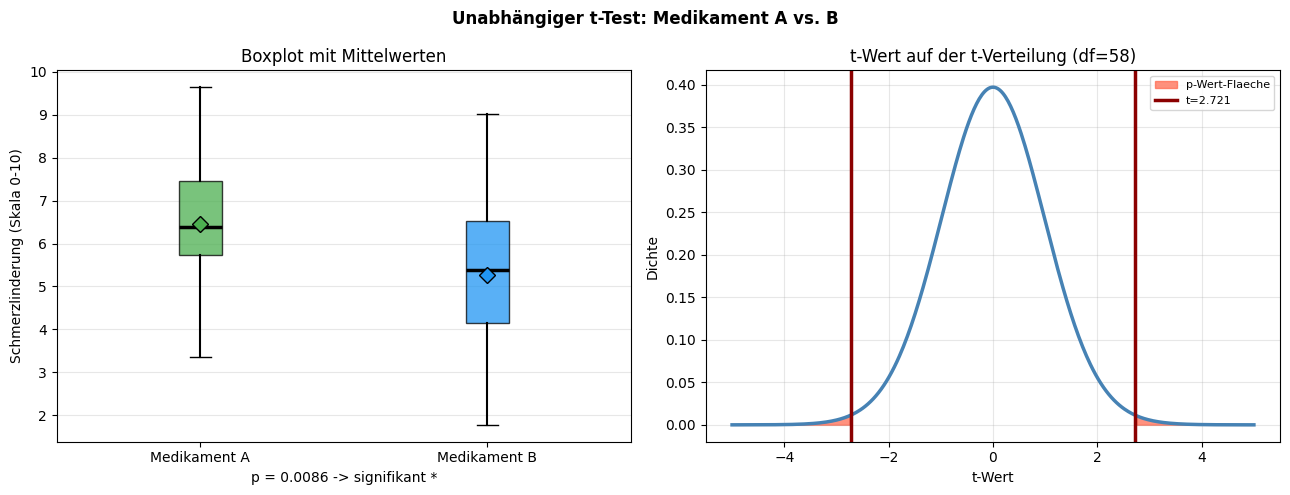

In [ ]:
# Unabhängiger t-Test: Medikament A vs. B (numiqo)
np.random.seed(42)
n_med = 30
medikament_a = pd.Series(np.random.normal(6.8, 1.8, n_med))  # Schmerzlinderung
medikament_b = pd.Series(np.random.normal(5.5, 1.9, n_med))

# Levene-Test (Varianzhomogenität)
lev_stat, lev_p = stats.levene(medikament_a, medikament_b)

# t-Test (Welch: equal_var=False ist sicherer)
t_u, p_u   = stats.ttest_ind(medikament_a, medikament_b, equal_var=True)
t_w, p_w   = stats.ttest_ind(medikament_a, medikament_b, equal_var=False)

# Manuell: gepoolte Standardabweichung
n1, n2 = len(medikament_a), len(medikament_b)
s1, s2 = medikament_a.std(ddof=1), medikament_b.std(ddof=1)
sp     = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
se_u   = sp * np.sqrt(1/n1 + 1/n2)
df_u   = n1 + n2 - 2

print("Unabhängiger t-Test: Medikament A vs. B")
print(f"H0: MW_A = MW_B  |  H1: MW_A != MW_B")
print()
print(f"Medikament A: n={n1}, MW={medikament_a.mean():.3f}, SD={s1:.3f}")
print(f"Medikament B: n={n2}, MW={medikament_b.mean():.3f}, SD={s2:.3f}")
print(f"Differenz:    {medikament_a.mean()-medikament_b.mean():.3f}")
print()
print(f"Levene-Test:  L={lev_stat:.4f}, p={lev_p:.4f} -> "
      + ("gleiche Varianzen (Standard-t-Test)" if lev_p > 0.05 else "ungleiche Varianzen (Welch)"))
print()
print(f"Gepoolte SD:  {sp:.4f}")
print(f"Standardfehler: {se_u:.4f}")
print(f"t-Wert:       {t_u:.4f}  (df={df_u})")
print(f"p-Wert:       {p_u:.4f}  -> {'signifikant *' if p_u < 0.05 else 'n.s.'}")
print()
print(f"Welch-t-Test: t={t_w:.4f}, p={p_w:.4f}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Unabhängiger t-Test: Medikament A vs. B", fontsize=12, fontweight="bold")

bp = axes[0].boxplot([medikament_a, medikament_b], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], ["#4CAF50", "#2196F3"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
axes[0].set_title("Boxplot mit Mittelwerten")
axes[0].set_ylabel("Schmerzlinderung (Skala 0-10)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Medikament A", "Medikament B"])
for idx, (d, fc) in enumerate([(medikament_a, "#4CAF50"), (medikament_b, "#2196F3")], 1):
    axes[0].plot(idx, d.mean(), "D", color=fc, markersize=8, zorder=5,
                 markeredgecolor="black")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xlabel("p = " + str(round(p_u, 4)) +
                   " -> " + ("signifikant *" if p_u < 0.05 else "n.s."))

# t-Verteilung
x_t = np.linspace(-5, 5, 400)
y_t = t_dist.pdf(x_t, df=df_u)
axes[1].plot(x_t, y_t, color="steelblue", linewidth=2.5)
axes[1].fill_between(x_t[x_t >= abs(t_u)],  y_t[x_t >= abs(t_u)],
                     color="tomato", alpha=0.7, label="p-Wert-Fläche")
axes[1].fill_between(x_t[x_t <= -abs(t_u)], y_t[x_t <= -abs(t_u)],
                     color="tomato", alpha=0.7)
axes[1].axvline( abs(t_u), color="darkred", linewidth=2.5,
                label="t=" + str(round(t_u, 3)))
axes[1].axvline(-abs(t_u), color="darkred", linewidth=2.5)
axes[1].set_title("t-Wert auf der t-Verteilung (df=" + str(df_u) + ")")
axes[1].set_xlabel("t-Wert")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Abhängiger t-Test (Gepaarter t-Test)

**Wann:** Dieselben Personen zu zwei Zeitpunkten (Vorher/Nachher)

**Beispiel (numiqo):** Gewicht **vor** und **nach** der Diät – dieselben 30 Personen.

**Berechnung basiert auf den Differenzen** $d_i = x_{\text{nachher},i} - x_{\text{vorher},i}$:
$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \quad df = n - 1$$

Abhängiger t-Test: Diät-Studie
H0: Mittlere Differenz = 0  |  H1: Mittlere Differenz != 0

n Paare:           30
MW Vorher:         79.742 kg
MW Nachher:        74.879 kg
MW Differenz (d):  -4.8635 kg
SD Differenz:      2.7933 kg
Standardfehler:    0.5100 kg
t-Wert:            -9.5365  (df=29)
p-Wert:            0.000000
95%-KI Differenz:  [-5.907, -3.820] kg

Die Diät hat das Gewicht signifikant verändert!
Kontrolle scipy: t=9.5365, p=0.000000


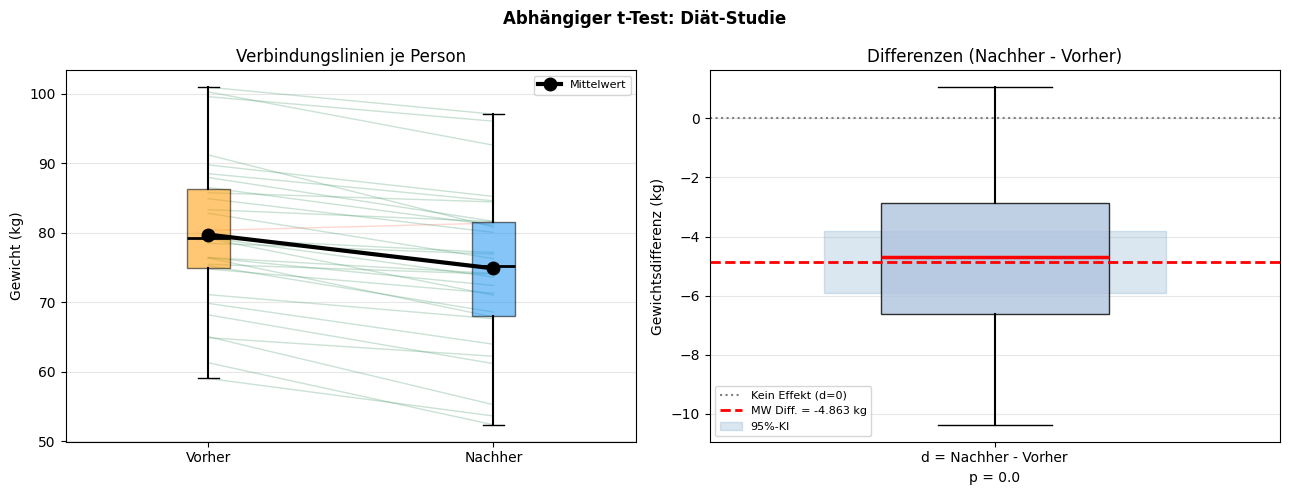

In [10]:
# Abhängiger t-Test: Diät-Beispiel (numiqo)
np.random.seed(42)
n_d = 30
gewicht_vorher = pd.Series(np.random.normal(82, 12, n_d))
gewicht_nachher = gewicht_vorher + np.random.normal(-4.5, 3.0, n_d)

differenzen = gewicht_nachher - gewicht_vorher
d_bar = differenzen.mean()
s_d   = differenzen.std(ddof=1)
se_d  = s_d / np.sqrt(n_d)
t_d   = d_bar / se_d
df_d  = n_d - 1
p_d   = 2 * t_dist.sf(abs(t_d), df=df_d)
ki_d  = t_dist.interval(0.95, df=df_d, loc=d_bar, scale=se_d)

print("Abhängiger t-Test: Diät-Studie")
print(f"H0: Mittlere Differenz = 0  |  H1: Mittlere Differenz != 0")
print()
print(f"n Paare:           {n_d}")
print(f"MW Vorher:         {gewicht_vorher.mean():.3f} kg")
print(f"MW Nachher:        {gewicht_nachher.mean():.3f} kg")
print(f"MW Differenz (d):  {d_bar:.4f} kg")
print(f"SD Differenz:      {s_d:.4f} kg")
print(f"Standardfehler:    {se_d:.4f} kg")
print(f"t-Wert:            {t_d:.4f}  (df={df_d})")
print(f"p-Wert:            {p_d:.6f}")
print(f"95%-KI Differenz:  [{ki_d[0]:.3f}, {ki_d[1]:.3f}] kg")
print()
if p_d < 0.05:
    print("Die Diät hat das Gewicht signifikant verändert!")
else:
    print("Kein signifikanter Gewichtsunterschied.")

t_scipy2, p_scipy2 = stats.ttest_rel(gewicht_vorher, gewicht_nachher)
print(f"Kontrolle scipy: t={t_scipy2:.4f}, p={p_scipy2:.6f}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Abhängiger t-Test: Diät-Studie", fontsize=12, fontweight="bold")

# Verbindungslinien
for i in range(n_d):
    fc = "seagreen" if differenzen.iloc[i] < 0 else "tomato"
    axes[0].plot([1, 2], [gewicht_vorher.iloc[i], gewicht_nachher.iloc[i]],
                 color=fc, alpha=0.25, linewidth=1)
axes[0].plot([1, 2], [gewicht_vorher.mean(), gewicht_nachher.mean()],
             "o-", color="black", linewidth=3, markersize=9, zorder=5,
             label="Mittelwert")
bp2 = axes[0].boxplot([gewicht_vorher, gewicht_nachher], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2),
                       whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp2["boxes"], ["#FF9800", "#2196F3"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.55)
axes[0].set_title("Verbindungslinien je Person")
axes[0].set_ylabel("Gewicht (kg)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Vorher", "Nachher"])
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Differenzen-Boxplot
axes[1].boxplot(differenzen, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                medianprops=dict(color="red", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5))
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1.5,
                label="Kein Effekt (d=0)")
axes[1].axhline(d_bar, color="red", linestyle="--", linewidth=2,
                label="MW Diff. = " + str(round(d_bar, 3)) + " kg")
axes[1].fill_between([0.7, 1.3], ki_d[0], ki_d[1],
                     alpha=0.2, color="steelblue", label="95%-KI")
axes[1].set_title("Differenzen (Nachher - Vorher)")
axes[1].set_ylabel("Gewichtsdifferenz (kg)")
axes[1].set_xticklabels(["d = Nachher - Vorher"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xlabel("p = " + str(round(p_d, 6)))

plt.tight_layout()
plt.show()

## 6. Einseitig vs. zweiseitig (numiqo-Empfehlung)

| | Zweiseitig | Einseitig |
|---|---|---|
| **Hypothese** | μ₁ ≠ μ₂ | μ₁ > μ₂ oder μ₁ < μ₂ |
| **Ablehnungsbereich** | Beide Seiten (je α/2) | Nur eine Seite (α) |
| **p-Wert Umrechnung** | Standard | p_ein = p_zwei / 2 |
| **Empfehlung** | **Standard – fast immer wählen** | Nur wenn Richtung vorab klar begründet |

> **numiqo:** Im Zweifel zweiseitig! Ein einseitiger Test übersieht jedes Signal
> in die entgegengesetzte Richtung – auch wenn es riesig ist.

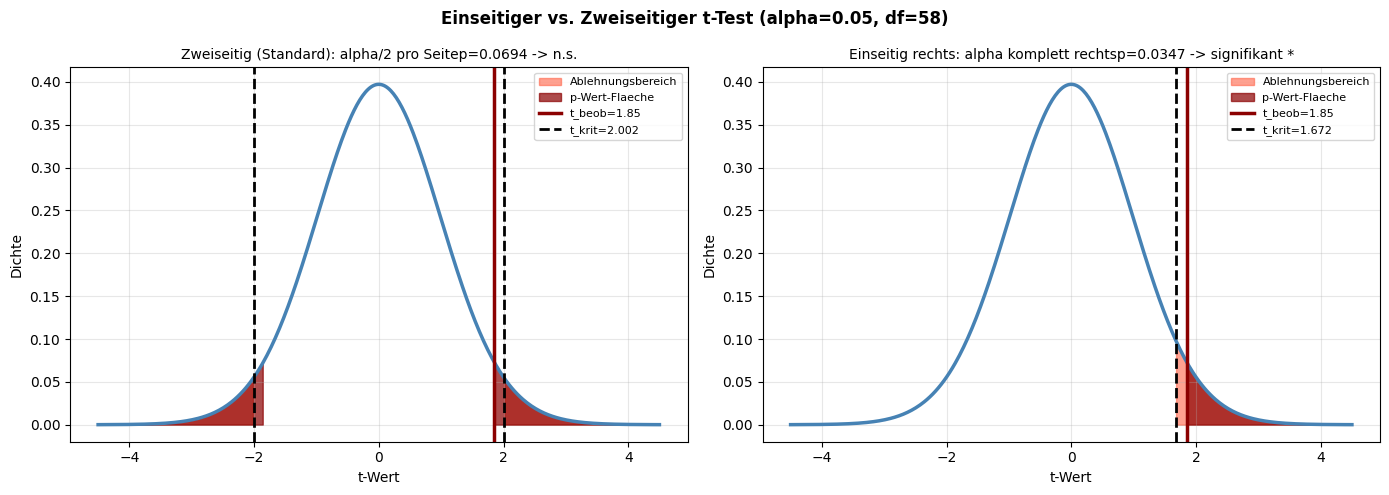

Derselbe t-Wert (1.85) fuehrt zu:
  p (zweiseitig) = 0.0694 -> nicht signifikant
  p (einseitig)  = 0.0347  -> signifikant


In [7]:
# Einseitig vs. zweiseitig auf der t-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Einseitiger vs. Zweiseitiger t-Test (alpha=0.05, df=58)",
             fontsize=12, fontweight="bold")

df_demo = 58
x_t = np.linspace(-4.5, 4.5, 400)
y_t = t_dist.pdf(x_t, df=df_demo)
alpha = 0.05
t_krit_2 = t_dist.ppf(1 - alpha/2, df=df_demo)
t_krit_1 = t_dist.ppf(1 - alpha,   df=df_demo)
t_beob   = 1.85

for ax, krit, seiten, titel in zip(
    axes,
    [t_krit_2, t_krit_1],
    [2, 1],
    ["Zweiseitig (Standard): alpha/2 pro Seite", "Einseitig rechts: alpha komplett rechts"]
):
    ax.plot(x_t, y_t, color="steelblue", linewidth=2.5)
    ax.fill_between(x_t[x_t >= krit], y_t[x_t >= krit],
                    color="tomato", alpha=0.6, label="Ablehnungsbereich")
    if seiten == 2:
        ax.fill_between(x_t[x_t <= -krit], y_t[x_t <= -krit],
                        color="tomato", alpha=0.6)
    ax.fill_between(x_t[x_t >= t_beob], y_t[x_t >= t_beob],
                    color="darkred", alpha=0.7, label="p-Wert-Flaeche")
    if seiten == 2:
        ax.fill_between(x_t[x_t <= -t_beob], y_t[x_t <= -t_beob],
                        color="darkred", alpha=0.7)
    ax.axvline(t_beob,  color="darkred", linewidth=2.5,
               label="t_beob=" + str(t_beob))
    ax.axvline(krit,    color="black",   linewidth=2, linestyle="--",
               label="t_krit=" + str(round(krit, 3)))
    if seiten == 2:
        ax.axvline(-krit, color="black", linewidth=2, linestyle="--")

    p = 2*t_dist.sf(t_beob, df=df_demo) if seiten == 2 else t_dist.sf(t_beob, df=df_demo)
    entsch = "signifikant *" if p < alpha else "n.s."
    ax.set_title(titel + "p=" + str(round(p, 4)) + " -> " + entsch, fontsize=10)
    ax.set_xlabel("t-Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Derselbe t-Wert (1.85) fuehrt zu:")
p_zwei_r = 2*t_dist.sf(t_beob, df=df_demo)
p_ein_r  = t_dist.sf(t_beob, df=df_demo)
print(f"  p (zweiseitig) = {p_zwei_r:.4f} -> {'signifikant' if p_zwei_r < 0.05 else 'nicht signifikant'}")
print(f"  p (einseitig)  = {p_ein_r:.4f}  -> {'signifikant' if p_ein_r < 0.05 else 'nicht signifikant'}")

## 7. Ergebnis berichten (wie numiqo)

**numiqo-Ausgabeformat** (APA-Stil):

> Ein zweiseitiger t-Test für unabhängige Stichproben (gleiche Varianzen angenommen)
> zeigte, dass der Unterschied zwischen Männlich und Weiblich in Bezug auf die
> abhängige Variable Einkommen statistisch nicht signifikant war,
> **t(10) = -1,93, p = 0,082, 95%-KI [-1399,36; 99,36]**.
> Die Nullhypothese wird damit beibehalten.

**Wichtige Bestandteile einer Ergebnisberichtung:**
- Art des Tests (unabh./abh./Einstichproben, ein-/zweiseitig)
- t-Wert mit Freiheitsgraden: `t(df) = X.XX`
- p-Wert: `p = .042` oder `p < .001`
- 95%-Konfidenzintervall
- Entscheidung (H₀ abgelehnt / nicht abgelehnt)

In [13]:
# Ergebnis-Funktion im numiqo-Stil
def t_test_bericht(gruppe1, gruppe2=None, mu0=None,
                   abhaengig=False, name1="Gruppe 1", name2="Gruppe 2",
                   zweiseitig=True, alpha=0.05):
    gruppe1 = np.asarray(gruppe1)

    if mu0 is not None:
        # Einstichproben
        t, p = stats.ttest_1samp(gruppe1, popmean=mu0)
        n, df = len(gruppe1), len(gruppe1)-1
        se = gruppe1.std(ddof=1) / np.sqrt(n)
        ki = t_dist.interval(0.95, df=df, loc=gruppe1.mean(), scale=se)
        print(f"Einstichproben-t-Test: {name1}")
        print(f"H0: mu = {mu0}  |  H1: mu != {mu0}" if zweiseitig else f"H0: mu = {mu0}")
        print(f"MW={gruppe1.mean():.3f}, SD={gruppe1.std(ddof=1):.3f}, n={n}")
    elif abhaengig:
        # Abhängig
        gruppe2 = np.asarray(gruppe2)
        t, p = stats.ttest_rel(gruppe1, gruppe2)
        d = gruppe2 - gruppe1
        n, df = len(d), len(d)-1
        se = d.std(ddof=1) / np.sqrt(n)
        ki = t_dist.interval(0.95, df=df, loc=d.mean(), scale=se)
        print(f"Abhängiger t-Test: {name1} vs. {name2}")
        print(f"H0: MW Differenz = 0")
        print(f"MW {name1}={gruppe1.mean():.2f}, MW {name2}={gruppe2.mean():.2f}, n={n}")
        print(f"MW Differenz={d.mean():.3f}, SD_d={d.std(ddof=1):.3f}")
    else:
        # Unabhängig
        gruppe2 = np.asarray(gruppe2)
        lev_s, lev_p = stats.levene(gruppe1, gruppe2)
        gleich = lev_p > 0.05
        t, p = stats.ttest_ind(gruppe1, gruppe2, equal_var=gleich)
        n1, n2 = len(gruppe1), len(gruppe2)
        df = n1 + n2 - 2 if gleich else None
        se_diff = np.sqrt(gruppe1.var()/n1 + gruppe2.var()/n2)
        diff    = gruppe1.mean() - gruppe2.mean()
        ki = t_dist.interval(0.95, df=n1+n2-2, loc=diff, scale=se_diff)
        print(f"Unabhägiger t-Test: {name1} vs. {name2}")
        print(f"Levene: L={lev_s:.3f}, p={lev_p:.4f} -> "
              + ("gleiche Varianzen" if gleich else "Welch-t-Test"))
        print(f"MW {name1}={gruppe1.mean():.2f} (n={n1}), "
              + f"MW {name2}={gruppe2.mean():.2f} (n={n2})")

    if not zweiseitig:
        p = p / 2
    entsch = "abgelehnt" if p < alpha else "nicht abgelehnt"

    print()
    print(f"t({n1+n2-2 if (gruppe2 is not None and not abhaengig) else df}) = {t:.3f},  "
          + f"p = {p:.4f},  95%-KI [{ki[0]:.3f}, {ki[1]:.3f}]")
    print(f"Ergebnis: H0 wird {entsch} (alpha={alpha})")
    if p < alpha:
        print("-> Statistisch signifikanter Unterschied!")
    else:
        print("-> Kein statistisch signifikanter Unterschied.")

# Alle drei Varianten
np.random.seed(42)
t_test_bericht(riegel, mu0=50.0, name1="Schokoriegel")
print()
t_test_bericht(medikament_a, medikament_b,
               name1="Medikament A", name2="Medikament B")
print()
t_test_bericht(gewicht_vorher, gewicht_nachher, abhaengig=True,
               name1="Vorher", name2="Nachher")

Einstichproben-t-Test: Schokoriegel
H0: mu = 50.0  |  H1: mu != 50.0
MW=47.341, SD=3.150, n=30

t(29) = -4.623,  p = 0.0001,  95%-KI [46.165, 48.518]
Ergebnis: H0 wird abgelehnt (alpha=0.05)
-> Statistisch signifikanter Unterschied!

Unabhägiger t-Test: Medikament A vs. Medikament B
Levene: L=0.602, p=0.4411 -> gleiche Varianzen
MW Medikament A=6.46 (n=30), MW Medikament B=5.27 (n=30)

t(58) = 2.721,  p = 0.0086,  95%-KI [0.330, 2.053]
Ergebnis: H0 wird abgelehnt (alpha=0.05)
-> Statistisch signifikanter Unterschied!

Abhängiger t-Test: Vorher vs. Nachher
H0: MW Differenz = 0
MW Vorher=79.74, MW Nachher=74.88, n=30
MW Differenz=-4.863, SD_d=2.793

t(29) = 9.537,  p = 0.0000,  95%-KI [-5.907, -3.820]
Ergebnis: H0 wird abgelehnt (alpha=0.05)
-> Statistisch signifikanter Unterschied!


## 8. Zusammenfassung

```
t-Test – Übersicht
│
├── GRUNDIDEE
│   t = Signal / Rauschen = Mittelwertsunterschied / Standardfehler
│   Grosses t -> kleines p -> H0 ablehnen
│
├── DREI VARIANTEN
│   ├── EINSTICHPROBEN-t-TEST
│   │   Stichproben-MW vs. bekannter Referenzwert
│   │   t = (x_quer - mu0) / (s / sqrt(n))
│   │   df = n - 1
│   │
│   ├── UNABHÄNGIGER t-TEST
│   │   Zwei getrennte Gruppen (verschiedene Personen)
│   │   t = (x1 - x2) / (sp * sqrt(1/n1 + 1/n2))
│   │   df = n1 + n2 - 2
│   │   Voraussetzung: Levene-Test auf Varianzhomogenität
│   │
│   └── ABHÄNGIGER t-TEST (gepaart)
│       Dieselben Personen zu 2 Zeitpunkten
│       t = d_bar / (s_d / sqrt(n))
│       df = n - 1  (Anzahl Paare)
│
├── VORAUSSETZUNGEN
│   Metrisches Skalenniveau
│   Normalverteilung (ab n>30 robust)
│   Varianzhomogenität (nur unabh., Levene-Test)
│   Zufallsstichprobe
│
├── ENTSCHEIDUNG
│   p < 0.05  -> H0 ablehnen (signifikant)
│   p >= 0.05 -> H0 nicht ablehnen
│   Im Zweifel: ZWEISEITIGER Test!
│
└── ERGEBNIS BERICHTEN (APA)
    t(df) = X.XX, p = .XXX, 95%-KI [u, o]
```

---
Quelle: [numiqo.de/tutorial/t-test](https://numiqo.de/tutorial/t-test)